# Rad sa izuzecima i standardnom bibliotekom
U prvom delu notebooka prikazani su osnovni koncepti rada sa izuzecima, kao i korišćenje ugrađenih funkcija i modula iz standardne biblioteke.

In [2]:
# Rad sa izuzecima

# Hvatanje izuzetka (try-except)

# 1. način - osnovno hvatanje greške bez detalja

try:
    rezultat=10/0
except ZeroDivisionError:
    print("Nije dozvoljeno deliti sa nulom!")

# 2. način - hvatanje greške i prikaz poruke iz objekta greške

try:
    rezultat=10/0
except ZeroDivisionError as e:
    print("Greska: ", e)

# 3. način - prikaz celog traceback-a (detaljan opis greške)
import traceback

try:
    rezultat=10/0
except ZeroDivisionError:
    traceback.print_exc()

Nije dozvoljeno deliti sa nulom!
Greska:  division by zero


Traceback (most recent call last):
  File "C:\Users\Dragica\AppData\Local\Temp\ipykernel_23516\365454167.py", line 23, in <module>
    rezultat=10/0
             ~~^~
ZeroDivisionError: division by zero


In [3]:
# Except blok bez navodjenja tipa izuzetka
try:
    rezultat=10/0
except:
    print("Greska!")

Greska!


In [4]:
# Više except blokova
try:
    lista=[1,2,3]
    print(lista[5])
except ZeroDivisionError:
    print("Deljenje sa nulom!")
except IndexError:
    print("Pogresan indeks u listi!")
except Exception:
    print("Desila se neka druga greska")

Pogresan indeks u listi!


In [5]:
# Finally blok
try:
    rezultat=10/2
except ZeroDivisionError:
    print("Nije dozvoljeno deliti sa nulom!")
finally:
    print("Ova poruka se uvek prikazuje")

Ova poruka se uvek prikazuje


In [6]:
# Rad sa datumima i vremenom (datetime modul)

import datetime

# Trenutni datum i vreme
now=datetime.datetime.now()
print("Trenutni datum i vreme:", now)

# Izvlačenje trenutnog datuma
today_date=datetime.date.today()
print("Trenutni datum: ", today_date)

# Definisanje konkretnog datuma
specific_date=datetime.date(2025,1,27)
print("Specifican datum: ", specific_date)

# Definisanje konkretnog vremena
specific_time=datetime.time(23,59,59)
print("Specificno vreme: ", specific_time)

# Definisanje konkretnog datetime objekta
specific_datetime=datetime.datetime(2025,1,27,23,59,59)
print("Specifican datum i vreme:", specific_datetime)

Trenutni datum i vreme: 2026-03-30 12:06:48.903617
Trenutni datum:  2026-03-30
Specifican datum:  2025-01-27
Specificno vreme:  23:59:59
Specifican datum i vreme: 2025-01-27 23:59:59


In [7]:
# str() funkcija – pretvara bilo koji objekat u njegovu tekstualnu (string) reprezentaciju
number=42
str_number=str(number)
print("String reprezentacija celog broja:",str_number)

pi=3.14
str_pi=str(pi)
print("String reprezentacija decimalnog broja:",str_pi)

my_list=[1,2,3,"four"]
str_list=str(my_list)
print("String reprezentacija liste:",str_list)

my_dict={"name":"Ana", "age":30}
str_dict=str(my_dict)
print("String reprezentacija recnika:",str_dict)

String reprezentacija celog broja: 42
String reprezentacija decimalnog broja: 3.14
String reprezentacija liste: [1, 2, 3, 'four']
String reprezentacija recnika: {'name': 'Ana', 'age': 30}


In [8]:
# type() funkcija - vraća tip podatka prosleđene vrednosti
number=10
print("Tip podatka promenljive number: ", type(number))

pi=3.14
print("Tip podatka promenljive pi: ", type(pi))

my_list=[1,2,3,4,5]
print("Tip podatka promenljive my_list: ", type(my_list))

my_dict={"name":"Ana", "age":30}
print("Tip podatka promenljive my_dict: ", type(my_dict))

Tip podatka promenljive number:  <class 'int'>
Tip podatka promenljive pi:  <class 'float'>
Tip podatka promenljive my_list:  <class 'list'>
Tip podatka promenljive my_dict:  <class 'dict'>


# Rad sa podacima u Pandasu
 Ovi primeri proširuju postojeći notebook kratkim uvodom u rad sa bibliotekama `pandas` i `matplotlib`.

1. Učitavanje CSV fajla pomoću `Path` i `pandas`
- Kreiramo konstantu `DATA_DIR` do direktorijuma sa podacima.
- Učitavamo fajl **Sales_January_2019.csv** koji sadrži kolone:
   `Order ID`, `Product`, `Quantity Ordered`, `Price Each`, `Order Date`, `Purchase Address`.

In [9]:
# Importovanje potrebnih biblioteka za rad sa podacima i grafikonima
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Putanja do direktorijuma sa podacima: /data/sales_data u okviru projekta
DATA_DIR = Path.cwd() / "data" / "sales_data"

In [11]:
# Učitati podatke za januar 2019.
jan_sales = pd.read_csv(DATA_DIR / "Sales_January_2019.csv")
# Prikazati prvih 5 redova
print("Prvih 5 redova:\n", jan_sales.head())

Prvih 5 redova:
   Order ID                   Product Quantity Ordered Price Each  \
0   141234                    iPhone                1        700   
1   141235  Lightning Charging Cable                1      14.95   
2   141236          Wired Headphones                2      11.99   
3   141237          27in FHD Monitor                1     149.99   
4   141238          Wired Headphones                1      11.99   

       Order Date                       Purchase Address  
0  01/22/19 21:25        944 Walnut St, Boston, MA 02215  
1  01/28/19 14:15       185 Maple St, Portland, OR 97035  
2  01/17/19 13:33  538 Adams St, San Francisco, CA 94016  
3  01/05/19 20:33     738 10th St, Los Angeles, CA 90001  
4  01/25/19 11:59          387 10th St, Austin, TX 73301  


# Brzi pregled strukture DataFrame‑a
Korisne metode za brzi uvid:
* `info()` – osnovne informacije o kolonama i tipovima podataka
* `shape` – dimenzije DataFrame‑a (redovi, kolone)
* `describe()` – statistika za numeričke kolone
* `sample()` – slučajni uzorak redova
* `value_counts()` – distribucija vrednosti u koloni

In [12]:
# Informacije o kolonama i nedostajućim vrednostima
jan_sales.info()
print("Dimenzije:", jan_sales.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9723 entries, 0 to 9722
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order ID          9697 non-null   object
 1   Product           9697 non-null   object
 2   Quantity Ordered  9697 non-null   object
 3   Price Each        9697 non-null   object
 4   Order Date        9697 non-null   object
 5   Purchase Address  9697 non-null   object
dtypes: object(6)
memory usage: 455.9+ KB
Dimenzije: (9723, 6)


In [13]:
# Deskriptivna statistika
print(jan_sales.describe())

        Order ID               Product Quantity Ordered Price Each  \
count       9697                  9697             9697       9697   
unique      9269                    20                8         19   
top     Order ID  USB-C Charging Cable                1      11.95   
freq          16                  1171             8795       1171   

        Order Date  Purchase Address  
count         9697              9697  
unique        8077              9161  
top     Order Date  Purchase Address  
freq            16                16  


In [14]:
# Slučajnih 3 reda
print(jan_sales.sample(3, random_state=42))

     Order ID                     Product Quantity Ordered Price Each  \
1145   142323  Bose SoundSport Headphones                1      99.99   
8501   149337    Apple Airpods Headphones                1        150   
3903   144933             Vareebadd Phone                1        400   

          Order Date                         Purchase Address  
1145  01/15/19 10:13  952 Jackson St, San Francisco, CA 94016  
8501  01/23/19 21:46        686 Lakeview St, Boston, MA 02215  
3903  01/15/19 09:44      275 1st St, San Francisco, CA 94016  


In [15]:
# Distribucija proizvoda (Top 5)
print(jan_sales["Product"].value_counts().head())

Product
USB-C Charging Cable        1171
AAA Batteries (4-pack)      1082
Lightning Charging Cable    1068
AA Batteries (4-pack)       1039
Wired Headphones            1005
Name: count, dtype: int64


# 3. Čišćenje i konverzija tipova podataka
Originalni CSV sadrži sve vrednosti kao stringove. Pretvoriti u odgovarajuće tipove:
* `Order Date` → `datetime`
* `Quantity Ordered`, `Price Each` → `int` / `float`

Takođe kolonu `Product` pretvoriti u **kategorijsku** promenljivu kako bi se smanjila potrošnja memorije.

In [16]:
# Konverzija kolona uz ignorisanje grešaka (nevažeći redovi biće NaN)

#NaT, NaN

jan_sales["Order Date"] = pd.to_datetime(jan_sales["Order Date"], format="%m/%d/%y %H:%M", errors="coerce")
jan_sales["Quantity Ordered"] = pd.to_numeric(jan_sales["Quantity Ordered"], errors="coerce")
jan_sales["Price Each"] = pd.to_numeric(jan_sales["Price Each"], errors="coerce")

print(jan_sales.dtypes)

Order ID                    object
Product                     object
Quantity Ordered           float64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
dtype: object


In [17]:
# Produkt kao kategorija
jan_sales["Product"] = jan_sales["Product"].astype("category")

print(jan_sales.dtypes)

Order ID                    object
Product                   category
Quantity Ordered           float64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
dtype: object


# 4. Primeri analize podataka
**a) Top 10 proizvoda po broju prodatih jedinica**

**b) Dnevni prihod tokom januara 2019.**

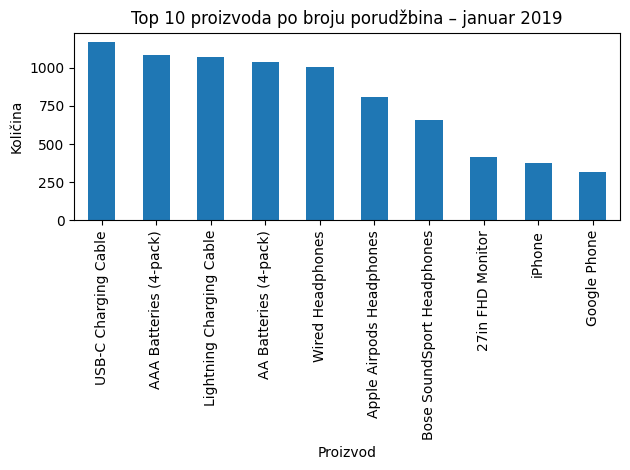

In [18]:
# a) Top 10 proizvoda po broju prodatih jedinica
plt.figure()
jan_sales["Product"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 proizvoda po broju porudžbina – januar 2019")
plt.xlabel("Proizvod")
plt.ylabel("Količina")
plt.tight_layout()
plt.show()

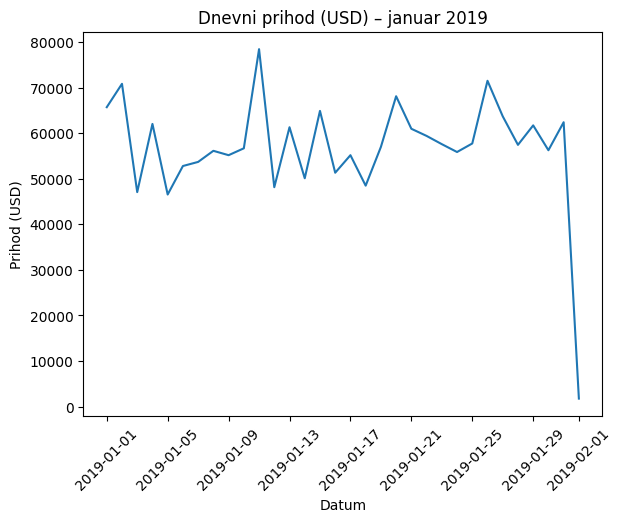

In [19]:
# b) Dnevni prihod tokom januara 2019
plt.figure()

# Kreiramo kolonu ukupan iznos jedne stavke (kolicina * cena)
jan_sales["Line Total"] = jan_sales["Quantity Ordered"] * jan_sales["Price Each"]

# Grupisanje po datumu (samo datum, bez vremena)
daily_revenue = jan_sales.groupby(jan_sales["Order Date"].dt.date)["Line Total"].sum()

daily_revenue.plot()
plt.title("Dnevni prihod (USD) – januar 2019")
plt.xlabel("Datum")
plt.ylabel("Prihod (USD)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

### 5. Rezime – ključne razlike tipova podataka

| Python tip            | Pandas ekvivalent        | Napomena                                             |
|-----------------------|--------------------------|------------------------------------------------------|
| `int`, `float`, `str` | `int64`, `float64`, `object` | Osnovni skalarni tipovi                         |
| `list` / `dict`       | `object`                 | Unutar ćelije – izbegavati za analizu               |
| `datetime`            | `datetime64[ns]`         | Efikasno čuvanje datuma i vremena                   |
| –                     | `category`               | Diskretni skup vrednosti, manja memorija i brže grupisanje |
| `bool`                | `bool`                   | `True` / `False` vrednosti                          |